# Normalization 
The Goal of normalization is to change the values of numeric columns in the dataset to use a common scale, without distorting differences in the ranges of values or losing information 

Normalization is a feature scaling technique that rescales numerical data to a fixed range, usually 0 to 1.

It ensures that all features have values within the same range, making them easier for many machine learning algorithms to process.

Formula (Min-Max Normalization):- x′= ​x−xmin​​/xmax​−xmin
<br>​
Where:
- x = Original value
- xmin = Minimum value of the feature
- xmax = Maximum value of the feature
- x′ = Normalized value
	​


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']
df.head()


,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


findfont: Failed to find font weight normal, now using 700.


<Axes: xlabel='Alcohol', ylabel='Density'>

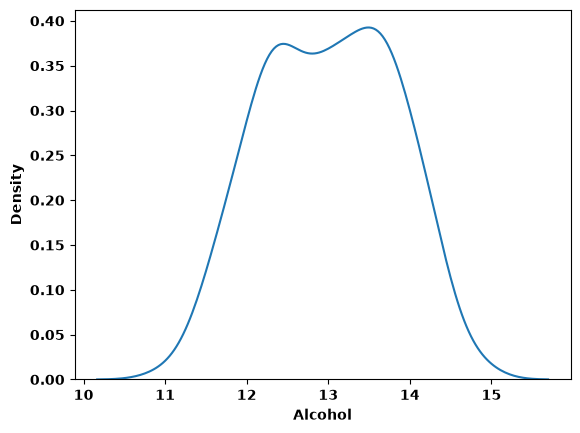

In [8]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

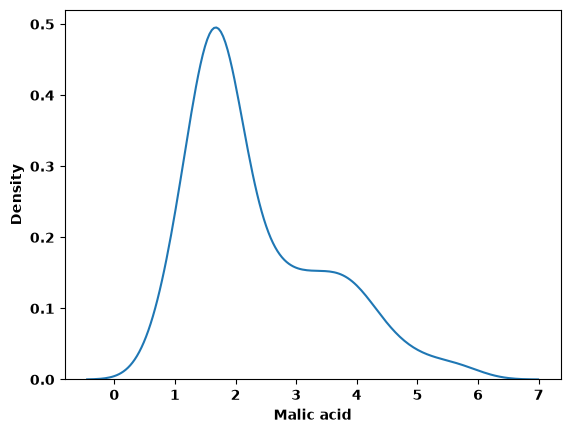

In [9]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

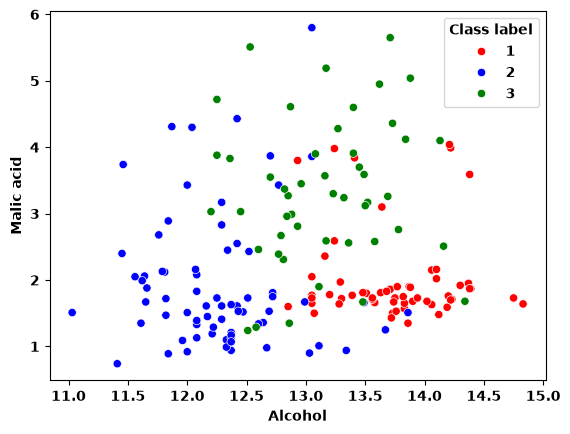

In [11]:
color_dict= {1:'red', 3:'green', 2:'blue'}
sns.scatterplot(
    x=df['Alcohol'],
    y=df['Malic acid'],
    hue=df['Class label'],
    palette=color_dict
)

Train dataset

In [12]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), 
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

#transfer train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [16]:
np.round(X_train_scaled.describe(), 1)


,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


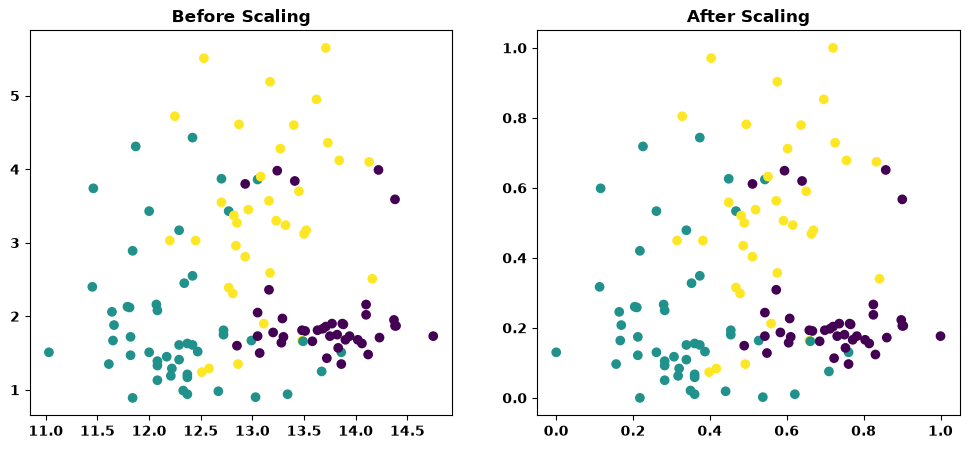

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
ax2.set_title("After Scaling")

plt.show()

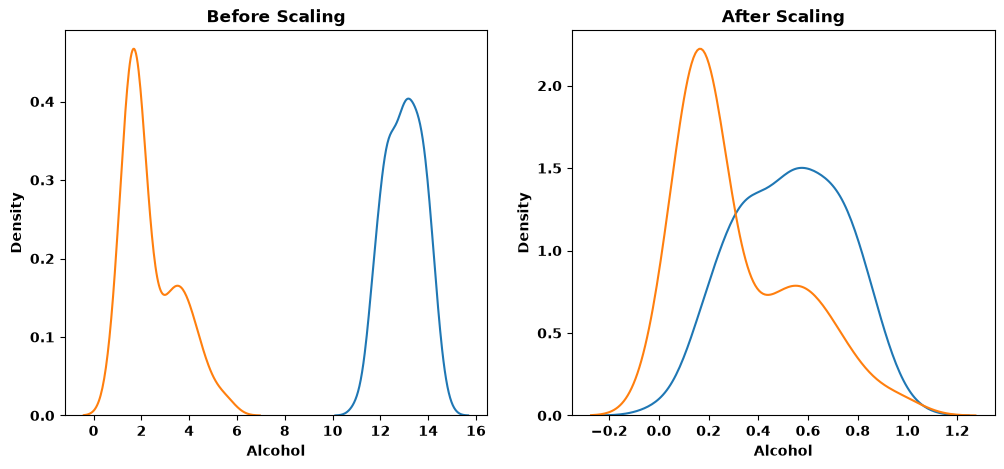

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
#before scaling 
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

#after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

## 1. Mean Normalization

### Definition

**Mean normalization** is a feature scaling technique that transforms data by subtracting the **mean** of the feature and dividing by the **range** (maximum − minimum).

Formula:  x′= x−Mean/Max−Min​

### How it is used

* Centers the data around **0**.
* Scales values so they lie approximately between **-1 and 1** (not always exactly).

### Best used when

* The data does **not contain many outliers**.
* You want the data to be centered around zero.
* Common in optimization and gradient-based machine learning algorithms.

---

## 2. Max Absolute Scaling (MaxAbsScaler)

### Definition

**Max Absolute Scaling** scales each feature by dividing every value by the **maximum absolute value** of that feature.

Formula: x′= x/∣xmax​∣​

### How it is used

* Scales values to the range **[-1, 1]**.
* Preserves **zero values** and the **sparsity** of the data.

### Best used when

* Working with **sparse datasets** (e.g., text data represented as bag-of-words or TF-IDF).
* Data is already centered around zero.
* You want to keep zero entries unchanged.

---

## 3. Robust Scaling (RobustScaler)

### Definition

**Robust Scaling** is a feature scaling technique that uses the **median** and **Interquartile Range (IQR)** instead of the mean and standard deviation.

Formula: x′= x−Median​/IQR

where,  IQR=Q3​−Q1​

### How it is used

* Centers the data using the **median**.
* Scales it using the **interquartile range**, making it less sensitive to extreme values.

### Best used when

* The dataset contains **many outliers**.
* The data is **skewed** rather than normally distributed.
* You want outliers to have minimal influence on scaling.

---

## Quick Comparison

| Scaling Method           | Uses                   | Best For                                              |
| ------------------------ | ---------------------- | ----------------------------------------------------- |
| **Mean Normalization**   | Mean and range         | Data without significant outliers; centering around 0 |
| **Max Absolute Scaling** | Maximum absolute value | Sparse datasets, text data, preserving zeros          |
| **Robust Scaling**       | Median and IQR         | Datasets with many outliers or skewed distributions   |
